`conda activate r_env_standr`

Taken from https://doi.org/10.1038/s43587-024-00613-3

In [ ]:
suppressPackageStartupMessages({
    library(reticulate)
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(lme4)
    library(numDeriv)
    library(dittoSeq)
    library(future)
    library(data.table)
    library(scales)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [ ]:
path_ref <- '/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds'
dmg <- readRDS(path_ref)
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <- AddMetaData(dmg, readRDS('../data/dmg_atlas_final_annotation_v2.rds'))

In [ ]:
dmg$lvl_4 <- droplevels(recode(dmg$lvl_4,
                   'cEndo'='Endothelial', 
'vEndo'='Endothelial', 
'aEndo'='Endothelial', 
'Endo_peri_2'='Endothelial', 
'CD4_naive'='T_cell', 
'CD8_effector'='T_cell', 
'CD8_early_exhaustion'='T_cell', 
'CD8_naive'='T_cell', 
'Plasma_B'='B_cell', 
'NK'='T_cell', 
'B_naive'='B_cell', 
'CD8_proliferative'='T_cell',  
'B_activated'='B_cell', 
'OPC'='OPC', 
'Astrocyte_fibrous'='Astrocyte', 
'Astrocyte_protoplasmic'='Astrocyte', 
'Peri_2'='Mural', 
'Fibro_type_1'='Mural', 
'Fibro_type_2'='Mural', 
'Peri_1'='Mural', 
'Fibro_type_3'='Mural', 
'SMC'='Mural', 
'Splatter'='Neuron', 
'Upper_rhomboic_lip'='Neuron', 
'Upper_layer_intratelencephalic'='Neuron', 
'Lower_rhomboic_lip'='Neuron', 
'Deep_layer_intratelencephalic'='Neuron', 
'Oligo_2'='Oligodendrocyte', 
'Oligo_1'='Oligodendrocyte',
                                'MG_homeostatic'='TAM_homeostatic',
                               'MDM_C1Q'='TAM_C1Q',
                               'MG_C1Q'='TAM_C1Q',
                               'MDM_lipid_metab'='TAM_lipid_laden',
                               'MG_lipid_metab'='TAM_lipid_laden',
                               'MG_IL1B'='TAM_IL1B',
                               'Neutrophil'='Mono_neutrophil',
                               'Monocyte'='Mono_neutrophil',
                               'MDM_scavenger'='TAM_scavenger',
                                'Dedifferentiated'='TD_like',
                                'GW_dedifferentiated'='GB_like',
                                'IPC_like'='nIPC_like'
))


In [ ]:
dmg <- subset(dmg, Study=='Ruiz2023')
dmg

An object of class Seurat 
19248 features across 205805 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <-  subset(dmg, lvl_2 %in% c('Stem_like',
                                  'Differentiated_like',
                                  'Myeloid'))

In [ ]:
sussman2024_malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_malignant.RDS')

In [ ]:
sussman2024_myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_myeloid.RDS')

In [ ]:
sussman2024_malignant$final <- sussman2024_malignant$predicted.atlas
sussman2024_myeloid$final <- sussman2024_myeloid$predicted.atlas
sussman2024 <- merge(sussman2024_malignant, sussman2024_myeloid)

In [ ]:
sussman2024$final <- recode(sussman2024$final,
                              'GBL_like'='GB_like') 

sussman2024$lvl_2 <- recode(sussman2024$final,
                              'RG_like'='Stem_like', 
                              'Tri_IPC_like'='Stem_like',
                              'nIPC_like'='Differentiated_like',
                              'OPC_like'='Stem_like',
                              'COP_like'='Differentiated_like',
                              'AC_like'='Differentiated_like',
                              'Cilia_like'='Differentiated_like',
                              'TD_like'='Differentiated_like',
                              'GW_like'='Differentiated_like',
                              'GB_like'='Differentiated_like',
                              'Mono_neutrophil'='Myeloid',
                              'TAM_C1Q'='Myeloid',
                              'TAM_lipid_laden'='Myeloid',
                              'TAM_scavenger'='Myeloid',
                              'TAM_IL1B'='Myeloid',
                              'TAM_homeostatic'  ='Myeloid'  
                     )

sussman2024$lvl_1 <- recode(sussman2024$lvl_2,
                              'Stem_like'='Malignant',
                              'Differentiated_like'='Malignant',
                              'Myeloid'='Immune'
                     )

sussman2024$Clinical_status <- recode(sussman2024$timepoint,
                              'Initial CNS Tumor'='Primary',
                              'Progressive (Autopsy)'='Recurrence',
                              'Progressive (Non-Autopsy)'='Recurrence'
                     )

sussman2024$lvl_4 <- sussman2024$final

sussman2024$SampleID <- sussman2024$orig.ident
sussman2024$cell <- rownames(sussman2024@meta.data)
dmg$cell <- rownames(dmg@meta.data)

dmg$patient_id <- dmg$ID
dmg$patient_id_detailed <- dmg$SampleID
sussman2024$patient_id_detailed <- sussman2024$SampleID

In [ ]:
sussman2024$Study <- 'Sussman2024'
sussman2024$Tumor_type <- recode(sussman2024$molecularClass,
                                'HGG - H3F3A K27M' = 'DMG H3 K27-altered',
                                'HGG - NOS'='DpHGG H3-wt and IDH-wt')

In [ ]:
# Extract metadata from each Seurat object
metadata1 <- dmg@meta.data
metadata2 <- sussman2024@meta.data

# Merge metadata with full outer join on common columns
merged_metadata <- full_join(metadata1, metadata2, by = intersect(names(metadata1), names(metadata2)))
rownames(merged_metadata) <- merged_metadata$cell

In [ ]:
clinical_status <- merged_metadata$Clinical_status

# Update Clinical_status for specific samples 
clinical_status[merged_metadata$SampleID == 'T20-90296_472AAL_diagnosis'] <- 'Primary'
clinical_status[merged_metadata$SampleID %in% c('T20-90296_472AAL_autopsy', 'T20-90296_472AAL_relapse')] <- 'Recurrence'

merged_metadata$Clinical_status <- factor(clinical_status, levels = unique(clinical_status))

In [ ]:
meta <- merged_metadata
meta

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.dmg.atlas.seuratv4.lvl_4.score,predicted.dmg.atlas.seuratv4.lvl_4,predicted.dmg.atlas.seuratv4.lvl_4_coarse.score,predicted.dmg.atlas.seuratv4.lvl_4_coarse,predicted.dmg.atlas.seuratv4.lvl_5.score,predicted.dmg.atlas.seuratv4.lvl_5,predicted.atlas.score,predicted.atlas,final,cell_labels1
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,BT042_PD,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
library("data.table")
library("tidyverse")
library("ggpubr")
library("magrittr")
library("lme4")
library("numDeriv")
library("scales")
library("stringr")

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ purrr     1.0.2
✔ lubridate 1.9.3     ✔ readr     2.1.5
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between() masks dplyr::between()
✖ readr::col_factor()   masks scales::col_factor()
✖ purrr::discard()      masks scales::discard()
✖ Matrix::expand()      masks tidyr::expand()
✖ dplyr::filter()       masks stats::filter()
✖ data.table::first()   masks dplyr::first()
✖ lubridate::hour()     masks data.table::hour()
✖ lubridate::isoweek()  masks data.table::isoweek()
✖ dplyr::lag()          masks stats::lag()
✖ data.table::last()    masks dplyr::last()
✖ lubridate::mday()     masks data.table::mday()
✖ lubridate::minute()   masks data.table::minute()
✖ lubri

In [ ]:
# Method and initial implementation by Natsuhiko Kumasaka (natsuhiko@github)
# refactored and maintained by Ni Huang (nh3@github)

#' Make cell type by sample count matrix
#'
#' This function makes cell type by sample count matrix from a cell level annotation table
#'
#' @param obs_tbl Cell level annotation table, such as AnnData.obs (data.frame-like object)
#' @param colSample Column in "obs_tbl" specifying sample ID (str)
#' @param colCelltype Column in "obs_tbl" specifying cell type annotation (str)
#'
#' @return matrix containing cell type counts of dimension nSample x nCelltype
#'
#' @import magrittr
.make_count_matrix <- function(obs_tbl, colSample, colCelltype) {
  cnt_mat <- table(obs_tbl[[colSample]], obs_tbl[[colCelltype]]) %>% as.matrix()
  cnt_mat
}

#' Make sample level metadata table
#'
#' This function makes sample level metadata table from a cell level annotation table
#'
#' @param obs_tbl Cell level annotation table, such as AnnData.obs (data.frame-like object)
#' @param colSample Column in "obs_tbl" specifying sample ID (str)
#' @param colVarCats Columns in "obs_tbl" specifying categorical variables to control for (vector of str)
#' @param colVarNums Columns in "obs_tbl" specifying numerical variables to control for (vector of str)
#' @param extra_term Extra term(s) to be added to the model (str or vector of str)
#'
#' @return tibble containing metadata for each sample, one per row
#'
#' @import dplyr
.make_sample_metadata <- function(obs_tbl, colSample, colVarCats = c(), colVarNums = c(), extra_term = NULL) {
  if (!is.null(extra_term)) {
    extra_vars <- unique(unlist(strsplit(extra_term, ":", fixed = T)))
    extra_vars <- extra_vars[extra_vars %in% colnames(obs_tbl)]
  } else {
    extra_vars <- c()
  }
  metadata_tbl <- obs_tbl %>%
    select(one_of(unique(c(colSample, colVarCats, colVarNums, extra_vars)))) %>%
    unique()
  metadata_tbl
}

#' Make input data for model fitting
#'
#' This function makes input data for model fitting by assembling sample level
#' metadata and cell type by sample count matrix
#'
#' @param Y Cell type by sample count matrix (matrix of dimension nSample x nCelltype)
#' @param metadata_tbl Sample level metadata table (data.frame-like object)
#'
#' @return tibble containing counts and metadata for each cell type in each sample
#'
#' @import tibble
#' @import dplyr
.make_input_for_glmer <- function(Y, metadata_tbl, colSample) {
  samples <- rownames(Y)
  celltypes <- colnames(Y)
  nSample <- length(samples)
  nCelltype <- length(celltypes)

  metadata_tbl <- metadata_tbl[match(samples, metadata_tbl[[colSample]]), ]

  input_tbl <- bind_cols(
    metadata_tbl[rep(1:nSample, nCelltype), ],
    enframe(factor(rep(celltypes, rep(nSample, nCelltype))), name = NULL, value = "Celltype")
  )

  input_tbl$Y <- as.vector(Y)
  cat("input prepared\n")

  input_tbl
}

#' Make model formula
#'
#' This function makes a formula for a GLMM with random effects for each
#' specified categorical variables and interactions between each variable and
#' cell type
#'
#' @param colSample Column in "obs_tbl" specifying sample ID (str)
#' @param colVarCats Columns in "obs_tbl" specifying categorical variables to control for (vector of str)
#' @param colVarNums Columns in "obs_tbl" specifying numerical variables to control for (vector of str)
#' @param extra_term Extra term(s) to be added to the model (str or vector of str)
#'
#' @return formula specifying a GLMM model
.make_formula <- function(colSample, colCelltype, colVarCats, colVarNums, extra_term = NULL) {
  if (!is.null(extra_term)) {
    extra_vars <- unique(unlist(strsplit(extra_term, ":", fixed = T)))
    extra_vars[extra_vars == colCelltype] <- "Celltype"
    extra_term <- sprintf("(1|%s)", paste(extra_vars, collapse = ":"))
  }
  terms <- c(
    colVarNums,
    sprintf("(1|%s)", c(colSample, colVarCats)),
    sprintf("(%s-1|Celltype)", colVarNums),
    sprintf("(1|%s:Celltype)", c(colSample, colVarCats))
  )
  formula_str <- paste(c("I(Y) ~ (1|Celltype)", terms, extra_term), collapse = "+")
  cat(paste0(formula_str, "\n"))
  as.formula(formula_str)
}

#' Get mean estimate of random effects and LTSR values for all specified variables
#'
#' This function extracts random effect estimates (mean and sd) of specified
#' variables, calculates LTSR using a z-score test and prepare categories in
#' specified orders for plotting
#'
#' @param ranef_tbl Table of random effect estimates (mean and sd) extracted from fitted model
#'     (data.frame-like object)
#' @param vars A list specifying required categorical sample metadata variables and their order,
#'     e.g. list(size=c('small', 'medium', 'big'), price=c('cheap', 'expensive'))
#' @param celltypes If specified, only keep those cell types (vector of str)
#' @param references If specified, fold changes are calculated relative to the specified level
#'     instead of global mean. Must be a list, e.g. list(size='small', price='cheap')
#'
#' @return tibble containing mean random effects and respective LTSR
#'
#' @import dplyr
#' @import tidyr
#' @import stringr
.getCondValLtsr <- function(ranef_tbl, vars, celltypes = NULL, references = NULL) {
  if (!is.list(vars)) stop('"vars" must be a list of which names are co-variables to plot', call. = F)
  if (!is.null(references) && !is.list(references)) stop('"references" must be a list of which names match that of "vars"', call. = F)

  cat_ranef_tbl <- ranef_tbl %>%
    filter(
      grepl(":Celltype$", grpvar)
    ) %>%
    mutate(
      grpvar = factor(sub(":Celltype$", "", grpvar)),
      grp = factor(ifelse(
        grepl(":.*:", grp),
        sapply(str_split(grp, ":"), function(x) paste(paste(x[-length(x)], collapse = ","), x[length(x)], sep = ":")),
        as.character(grp)
      ))
    ) %>%
    separate(
      grp,
      into = c("grpval", "Celltype"), sep = ":"
    )

  num_ranef_tbl <- ranef_tbl %>%
    filter(
      grpvar == "Celltype" & term != "(Intercept)"
    ) %>%
    mutate(
      grpvar = factor(term),
      grpval= paste("Slope",term, sep = "-"),
      Celltype = grp
    ) %>%
    select (
      -grp
    )

  if (!is.null(references)) {
    cat_ranef_tbl <- bind_rows(
      lapply(names(vars), function(vname) {
        if (vname %in% names(references)) {
          ref <- references[[vname]]
          full_join(
            cat_ranef_tbl %>% filter(grpvar == vname, grpval != ref),
            cat_ranef_tbl %>% filter(grpvar == vname, grpval == ref) %>% select(grpvar, Celltype, condval, condsd),
            by = c("grpvar", "Celltype")
          ) %>%
            mutate(
              condval = condval.x - condval.y,
              condsd = sqrt(condsd.x^2 + condsd.y^2)
            ) %>%
            select(-condval.x, -condval.y, -condsd.x, -condsd.y)
        } else {
          return(cat_ranef_tbl %>% filter(grpvar == vname))
        }
      })
    )
  }

  ranef_tbl <- bind_rows(cat_ranef_tbl, num_ranef_tbl)

  ranef_tbl <- ranef_tbl %>%
    mutate(
      lfsr = pnorm(condval, 0, condsd)
    ) %>%
    mutate(
      lfsr = ifelse(lfsr > 0.5, 1 - lfsr, lfsr)
    ) %>%
    mutate(
      ltsr = 1 - lfsr
    ) %>%
    select(
      grpvar, grpval, Celltype, condval, ltsr
    )

  if (!is.null(celltypes)) ranef_tbl <- ranef_tbl %>% filter(Celltype %in% celltypes)

  ranef_tbl <- ranef_tbl %>%
    filter(
      grpvar %in% names(vars)
    ) %>%
    mutate(
      grpvar = factor(grpvar, levels = names(vars)),
      grpval = factor(grpval, levels = unlist(vars, use.names = F))
    )

  ranef_tbl
}

#' Cell type composition analysis
#'
#' This function performs cell type composition analysis across samples grouped by certain metadata
#' variable while controling for other variables, by fitting a Poisson Generalised Linear Mixed
#' Model
#'
#' @param obs_tbl Cell level annotation table, such as AnnData.obs (data.frame-like object)
#' @param colSample Column in "obs_tbl" specifying sample ID (str)
#' @param colCelltype Column in "obs_tbl" specifying cell type annotation (str)
#' @param colVarCats Columns in "obs_tbl" specifying categorical variables to control for (vector of str)
#' @param colVarNums Columns in "obs_tbl" specifying numerical variables to control for (vector of str)
#' @param extra_term Extra term(s) to be added to the model (str or vector of str)
#' @param save If specified, used as file name prefix to save returned values (str)
#'
#' @return list containing two tables, 1) estimated random effects, 2) estimated explained variance
#'     (in the form of standard deviation)
#'
#' @import tibble
#' @import dplyr
#' @import tidyr
#' @import lme4
#' @import numDeriv
#'
#' @export
CellTypeCompositionAnalysis <- function(obs_tbl, colSample, colCelltype, colVarCats, colVarNums = NULL, extra_term = NULL, save = NULL) {
  metadata_tbl <- .make_sample_metadata(obs_tbl, colSample, colVarCats, colVarNums, extra_term = extra_term)
  Y <- .make_count_matrix(obs_tbl, colSample, colCelltype)

  input_tbl <- .make_input_for_glmer(Y, metadata_tbl, colSample)

  f <- .make_formula(colSample, colCelltype, colVarCats, colVarNums, extra_term = extra_term)
  cat("model constructed\n")
  res.prop <- glmer(
    f,
    data = input_tbl, family = poisson,
    control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
  )
  cat("model fitted\n")

  # standard errors of standard deviations (squre root of the variance parameters)
  devfun <- update(res.prop, devFunOnly = T)
  pars <- getME(res.prop, c("theta", "fixef"))
  hess <- hessian(devfun, unlist(pars))
  sdse.prop <- data.frame(sd = unlist(pars), se = sqrt(diag(solve(hess))))
  sdse_tbl <- sdse.prop %>%
    rownames_to_column() %>%
    as_tibble()
  # posterior means and their standard deviations
  res.prop.ranef <- ranef(res.prop)
  ranef_tbl <- data.frame(res.prop.ranef) %>% as_tibble()

  if (is.character(save)) {
    output_dir <- ifelse(grepl("[/]$", save), save, dirname(save))
    if (!dir.exists(output_dir)) dir.create(output_dir, recursive = T)
    output_sep <- ifelse(grepl("[/.]$", save), "", ".")
    write_tsv(ranef_tbl, paste(save, "ranef.tsv", sep = output_sep))
    write_tsv(sdse_tbl, paste(save, "sdse.tsv", sep = output_sep))
  }

  list(ranef = ranef_tbl, sdse = sdse_tbl)
}

#' Plot variable explained variance
#'
#' This function plots (square root of) variance explained by variables as a forest plot
#'
#' @param sdse_tbl Table containing square-root of estimated explained variance and standard errors
#'     (data.frame-like object)
#' @param colSample Column in "obs_tbl" specifying sample ID (str)
#' @param ci Confidence interval level (numeric between 0 and 1, default 0.95)
#'
#' @return ggplot object of a forest plot
#'
#' @import dplyr
#' @import ggplot2
#'
#' @export
plot_sdse <- function(sdse_tbl, colSample, ci = 0.95, xlim = c(-0.5, 1.5)) {
  n_se <- qnorm(1 - (1 - ci) / 2)
  p_tbl <- sdse_tbl %>%
    filter(
      grepl(":Celltype.\\(Intercept\\)", rowname)
    ) %>%
    mutate(
      rowname = sub(paste0("^", colSample, "$"), "Residual", sub("theta.(.*):Celltype.*", "\\1", rowname))
    ) %>%
    arrange(sd) %>%
    mutate(
      rowname = factor(rowname, levels = c("Residual", rowname[rowname != "Residual"]))
    ) %>%
    mutate(ci_l = sd - se * n_se, ci_h = sd + se * n_se)
  p <- (
    ggplot(p_tbl, aes(x = sd, y = rowname)) +
      geom_point(shape = 18, size = 3) +
      geom_errorbarh(aes(xmin = ci_l, xmax = ci_h), height = 0) +
      geom_vline(xintercept = 0, lty = 2) +
      xlab("Square root of explained variance") +
      coord_cartesian(xlim = xlim) +
      theme_bw() +
      theme(axis.title.y = element_blank())
  )
}

#' Plot estimated random effects of variables
#'
#' This function plots random effects of variables on cell type composition as a dot plot
#'
#' @param ranef_tbl Table of random effect estimates (mean and sd) extracted from fitted model
#'     (data.frame-like object)
#' @param vars A list specifying required categorical sample metadata variables and their order,
#'     e.g. list(size=c('small', 'medium', 'big'), price=c('cheap', 'expensive'))
#' @param celltypes If specified, only keep those cell types (vector of str)
#' @param celltype_order Determine how cell types are ordered. Either "hclust" which orders by
#'     hierarchical clustering, or a vector of cell types. (str or vector of str)
#' @param references If specified, fold changes are calculated relative to the specified level
#'     instead of global mean. Must be a list, e.g. list(size='small', price='cheap')
#' @param maxFC Cap fold change by this value (numeric, default 3)
#' @param LTSR2p Whether to convert LTSR to p value (logical, default FALSE)
#' @param filterLtsr Only keeps cell types of which at least one LTSR is greater or equal to
#'     specified value. (numeric, default 0)
#' @param swap_axes Whether to swap axis when plotting (logical, default FALSE)
#'
#' @return ggplot object of a dot plot
#'
#' @import dplyr
#' @import ggplot2
#' @importFrom scales squish
#'
#' @export
plot_ranef <- function(ranef_tbl, vars, celltypes = NULL, celltype_order = "hclust", references = NULL,
                       maxFC = 3, LTSR2p = F, highlightLtsr = 0.0, filterLtsr = 0.0, swap_axes = F) {
  ranef_tbl <- .getCondValLtsr(ranef_tbl, vars, celltypes = celltypes, references = references)

  condval_mat <- ranef_tbl %>%
    select(
      Celltype, grpval, condval
    ) %>%
    spread(
      "grpval", "condval"
    ) %>%
    column_to_rownames(
      var = "Celltype"
    ) %>%
    as.matrix()
  if (length(celltype_order) == 1 && celltype_order == "hclust") {
    dendy <- hclust(dist(condval_mat))
    ordered_celltype <- rownames(condval_mat)[dendy$ord]
  } else if (!is.null(celltype_order) && length(celltype_order) == dim(condval_mat)[1]) {
    ordered_celltype <- celltype_order
  }

  ranef_tbl <- ranef_tbl %>% mutate(
    Celltype = factor(Celltype, levels = ordered_celltype),
    condval = condval %>% pmin(log(maxFC)) %>% pmax(log(1 / maxFC)),
    ltsr = ltsr %>% pmin(0.9999) %>% pmax(0.5)
  )

  if (swap_axes) {
    ranef_tbl$Celltype <- factor(ranef_tbl$Celltype, levels = rev(levels(ranef_tbl$Celltype)))
    ranef_tbl$grpval <- factor(ranef_tbl$grpval, levels = rev(levels(ranef_tbl$grpval)))
  }

  if (filterLtsr > 0) {
    filtered_celltypes <- ranef_tbl %>%
      group_by(Celltype) %>%
      summarise(maxLtsr = max(ltsr)) %>%
      dplyr::filter(maxLtsr >= filterLtsr) %>%
      select(Celltype) %>%
      unlist(use.names = F)
    ranef_tbl <- ranef_tbl %>% dplyr::filter(Celltype %in% filtered_celltypes)
  }

  geom_dots <- geom_point(
    aes(
      fill = log2(exp(condval)),
      size = -log10(1 - ltsr)
    ),
    color = "white",
    shape = 21
  )

  if (swap_axes) {
    p <- (
      ggplot(ranef_tbl, aes(y = grpval, x = Celltype)) +
        facet_grid(grpvar ~ ., scales = "free_y", space = "free_y", switch = "x") +
        geom_dots
    )
  } else {
    p <- (
      ggplot(ranef_tbl, aes(x = grpval, y = Celltype)) +
        facet_grid(. ~ grpvar, scales = "free_x", space = "free_x", switch = "x") +
        geom_dots
    )
  }

  p <- (
    p + scale_fill_distiller(
      palette = "RdBu",
      limits = log2(c(1 / maxFC, maxFC)),
      breaks = log2(c(1 / maxFC, maxFC)),
      labels = c(paste0("1/", maxFC), maxFC),
      oob = squish,
      guide = guide_colorbar(
        title = "Fold change", title.position = "top", direction = "horizontal",
        barwidth = 5, barheight = 0.75, raster = F, order = 1)
    )
    + scale_size(
      limits = -log10(1 - c(0.5, 0.9999)),
      breaks = -log10(1 - c(0.5, 0.9, 0.99, 0.999, 0.9999)),
      range = c(0.5, 9),
      labels = ifelse(
        rep(LTSR2p, 5),
        c("0.5", "0.1", "0.01", "0.001", "<0.0001"),
        c("0.5", "0.9", "0.99", "0.999", ">0.9999")
      ),
      guide = guide_legend(
        title = ifelse(LTSR2p, "p", "LTSR"), reverse = T, order = 2,
        override.aes = list(fill = "black", color = "white")
      )
    )
    + theme_bw()
    + theme(
      axis.title.x = element_blank(),
      axis.title.y = element_blank(),
      strip.placement = "outside",
      strip.background = element_blank(),
      legend.spacing.y = unit(0.5, "line")
    )
  )

  if (highlightLtsr > 0) {
    p <- (
      p + geom_point(
        aes(
          color = ltsr > highlightLtsr,
          alpha = ltsr > highlightLtsr
        ),
        shape = 21, size = 9
      )
      + scale_color_manual(
        label = c(
          "", ifelse(LTSR2p, paste0("p < ", 1 - highlightLtsr), paste0("LTSR > ", highlightLtsr))
        ),
        values = c("white", "red"),
        guide = guide_legend(title = NULL, override.aes = list(size = 9), reverse = T, order = 3)
      )
      + scale_alpha_manual(values = c(0, 1), guide = F)
    )
  }

  p
}

#' Theme that mimics dotplots generated by Natsuhiko's code
#'
#' This function sets a number of options in ggplot2::theme() to mimic the style
#' of dotplots generated by Natsuhiko's code
#'
#' @param ... options passed to ggplot2::theme()
#'
#' @importFrom ggplot2 theme
#'
#' @export
theme_ctca <- function(...) {
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.ticks = element_blank(),
    strip.text = element_blank(),
    panel.grid = element_blank(),
    panel.border = element_blank(),
    ...
  )
}

#### Tumor type

In [ ]:
celltypes <- c('RG_like', 'GB_like','Tri_IPC_like','nIPC_like','OPC_like',
'COP_like','AC_like','Cilia_like','TD_like','GW_like',
'Mono_neutrophil',
'TAM_C1Q','TAM_lipid_laden','TAM_scavenger','TAM_IL1B','TAM_homeostatic'
                                )

In [ ]:
ltsr <- CellTypeCompositionAnalysis(obs_tbl=meta, 
                            colSample='patient_id_detailed', 
                            colCelltype='lvl_4', 
                            colVarCats=c('Tumor_type'))

input prepared
I(Y) ~ (1|Celltype)+(1|patient_id_detailed)+(1|Tumor_type)+(1|patient_id_detailed:Celltype)+(1|Tumor_type:Celltype)
model constructed


boundary (singular) fit: see help('isSingular')



model fitted


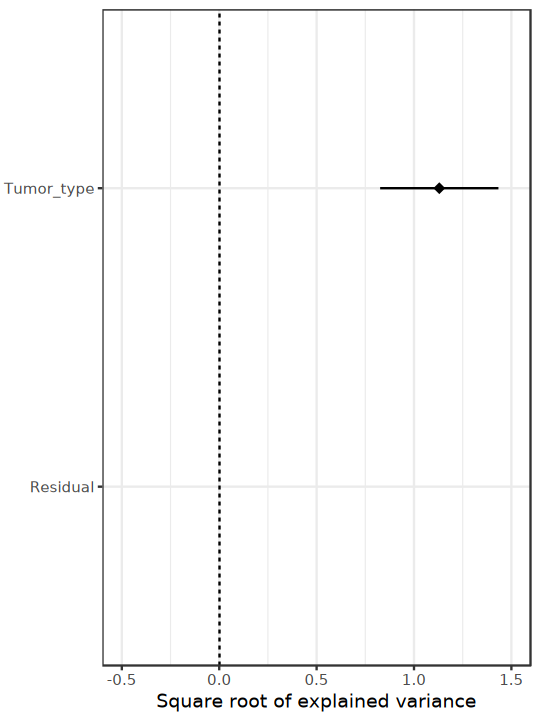

In [ ]:
options(repr.plot.height = 6, repr.plot.width = 4.5)
p <- plot_sdse(ltsr$sdse, 'patient_id_detailed')
p

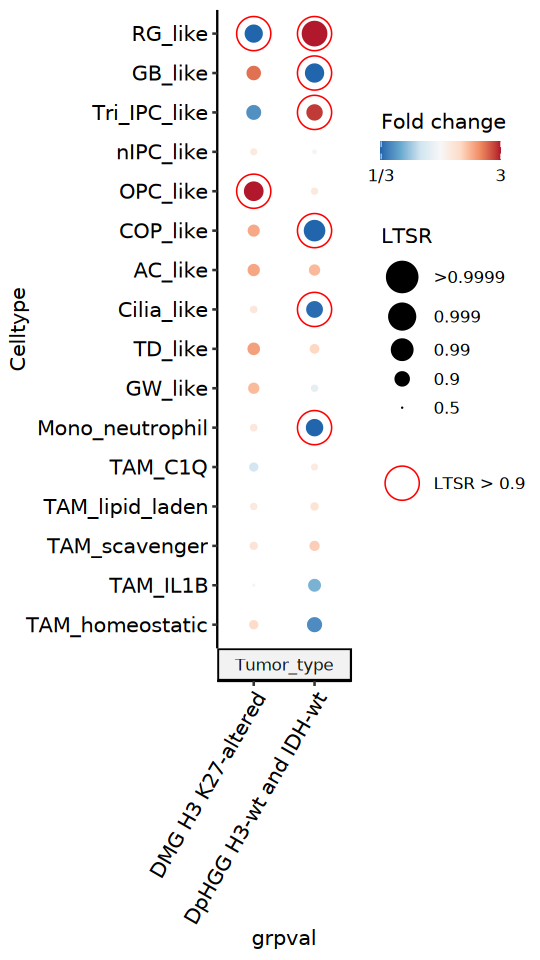

In [ ]:
options(repr.plot.height = 8, repr.plot.width = 4.5)
plt_gen = plot_ranef(ltsr$ranef, 
                     vars=list('Tumor_type'=unique(meta[['Tumor_type']])),
                    celltypes=celltypes,
                    celltype_order=rev(celltypes),
                     highlightLtsr = 0.9) + theme_pubr(legend = "right") +
   theme(panel.grid.major=element_blank(), panel.grid.minor=element_blank(),
         axis.text.x=element_text(angle=60, vjust=1, hjust=1))
plt_gen

In [ ]:
ggsave('figures/LTSR_tumor_type_Ruiz_Sussman.pdf', width = 4, height = 5.5)

#### Clinical_status

In [ ]:
ltsr <- CellTypeCompositionAnalysis(obs_tbl=meta %>% filter(Tumor_type %in% c('DpHGG H3-wt and IDH-wt')), 
                            colSample='patient_id_detailed', 
                            colCelltype='lvl_4', 
                            colVarCats=c('Clinical_status'))

input prepared
I(Y) ~ (1|Celltype)+(1|patient_id_detailed)+(1|Clinical_status)+(1|patient_id_detailed:Celltype)+(1|Clinical_status:Celltype)
model constructed


boundary (singular) fit: see help('isSingular')



model fitted


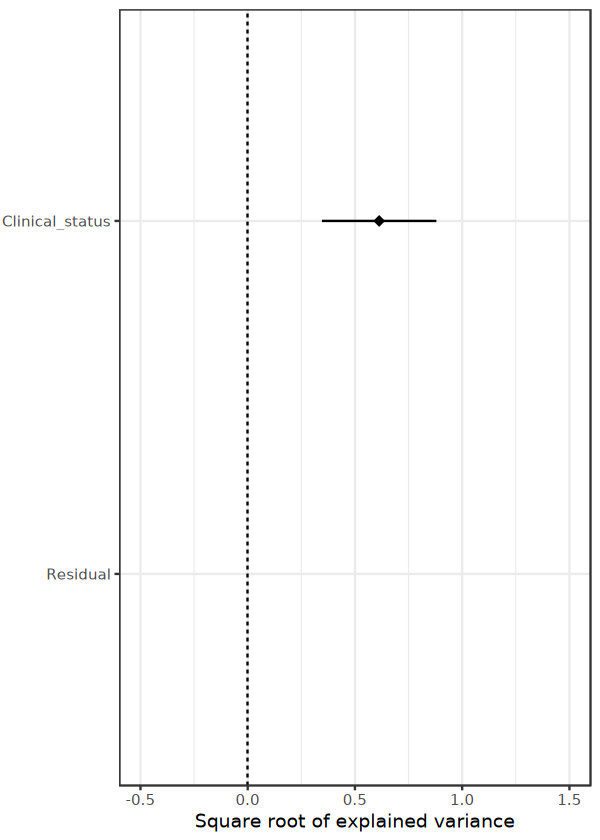

In [ ]:
p <- plot_sdse(ltsr$sdse, 'patient_id_detailed')
p

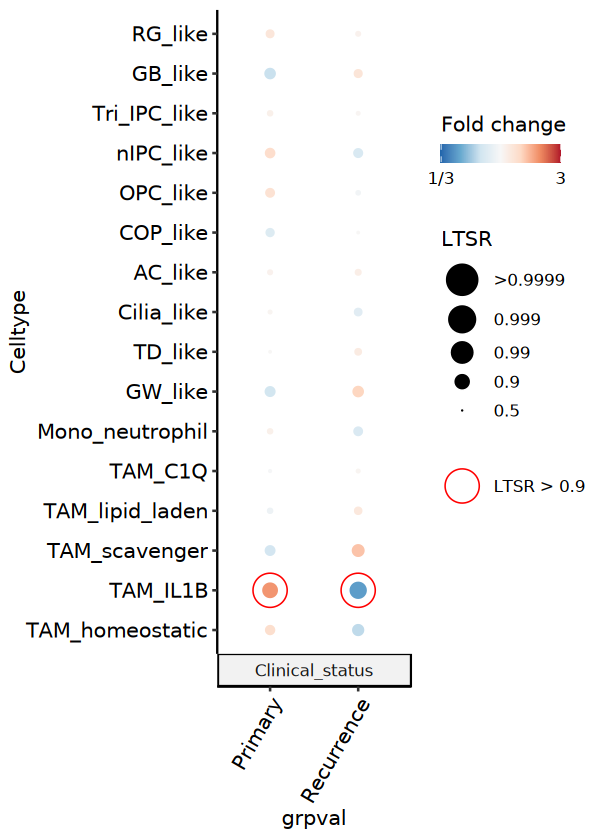

In [ ]:
options(repr.plot.height = 7, repr.plot.width = 5)
plt_gen = plot_ranef(ltsr$ranef, 
                     vars=list(Clinical_status=c('Primary', 'Recurrence')),
                     celltypes=celltypes,
                celltype_order=rev(celltypes),
                     highlightLtsr = 0.9) + theme_pubr(legend = "right") +
   theme(panel.grid.major=element_blank(), panel.grid.minor=element_blank(),
         axis.text.x=element_text(angle=60, vjust=1, hjust=1))
plt_gen